# Enhanced LNN Model v2 - Domain-Driven Cleaning
Training an improved Liquid Neural Network using temporally cleaned data with advanced anti-overfitting strategies

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("📚 Libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🚀 CUDA available: {torch.cuda.is_available()}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Using device: {device}")

📚 Libraries imported successfully!
🔥 PyTorch version: 2.2.0
🚀 CUDA available: False
💻 Using device: cpu


In [2]:
# Load the cleaned and processed data
print("📂 LOADING ENHANCED CLEANED DATASET")
print("=" * 50)

with open('data/enhanced_training_data_cleaned.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract data components
X_train = data['X_train']
X_val = data['X_val']
y_train = data['y_train']
y_val = data['y_val']
scaler_X = data['scaler_X']
scaler_y = data['scaler_y']
input_features = data['input_features']
target_features = data['target_features']
sequence_length = data['sequence_length']

print(f"✅ Data loaded successfully!")
print(f"📊 Training data: {X_train.shape} -> {y_train.shape}")
print(f"📊 Validation data: {X_val.shape} -> {y_val.shape}")
print(f"🔧 Input features ({len(input_features)}): {input_features}")
print(f"🎯 Target features ({len(target_features)}): {target_features}")
print(f"⏰ Sequence length: {sequence_length}")
print(f"🧹 Cleaning info: {data['cleaning_info']}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

print(f"🔥 Tensors moved to {device}")

📂 LOADING ENHANCED CLEANED DATASET
✅ Data loaded successfully!
📊 Training data: (123209, 10, 14) -> (123209, 3)
📊 Validation data: (30803, 10, 14) -> (30803, 3)
🔧 Input features (14): ['InletTemp', 'InletFlow', 'AirFuelRatio', 'FuelGasFlow', 'FuelGasMW', 'FuelGasDensity', 'SpecificGravity', 'WobbeIndex', 'AFR_Stoichiometric', 'FuelMassFlow', 'ActualHeatInput', 'ExcessAirRatio', 'CombustionEfficiency', 'ThermalEfficiency']
🎯 Target features (3): ['OutletTemp', 'ExcessO2', 'TempRise']
⏰ Sequence length: 10
🧹 Cleaning info: {'outliers_removed': 'domain_driven_temporal_analysis', 'cleaning_method': 'absolute_difference_threshold', 'final_data_retention': '100.0%'}
🔥 Tensors moved to cpu


In [3]:
# Enhanced Liquid Neural Network with Comprehensive Anti-Overfitting
class EnhancedLiquidNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.5):
        super(EnhancedLiquidNeuralNetwork, self).__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        
        # Input preprocessing layer
        self.input_projection = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)  # Less aggressive dropout for input
        )
        
        # Liquid layers with residual connections
        self.liquid_layers = nn.ModuleList()
        for i in range(num_layers):
            self.liquid_layers.append(
                nn.Sequential(
                    nn.Linear(hidden_size, hidden_size),
                    nn.LayerNorm(hidden_size),
                    nn.Tanh(),  # Bounded activation for stability
                    nn.Dropout(dropout)
                )
            )
        
        # LSTM for temporal dynamics
        self.lstm = nn.LSTM(
            hidden_size, hidden_size, 
            num_layers=1, 
            batch_first=True, 
            dropout=0 if num_layers == 1 else dropout * 0.5
        )
        
        # Attention mechanism
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            dropout=dropout * 0.3,
            batch_first=True
        )
        
        # Output layers with progressive size reduction
        self.output_layers = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.LayerNorm(hidden_size // 4),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            
            nn.Linear(hidden_size // 4, output_size)
        )
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.5)  # Smaller gain for stability
            if module.bias is not None:
                torch.nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape
        
        # Process each timestep
        liquid_outputs = []
        
        for t in range(seq_len):
            # Get current timestep
            x_t = x[:, t, :]
            
            # Input projection
            h = self.input_projection(x_t)
            
            # Liquid layers with residual connections
            for liquid_layer in self.liquid_layers:
                h_new = liquid_layer(h)
                h = h + h_new  # Residual connection
            
            liquid_outputs.append(h.unsqueeze(1))
        
        # Stack liquid outputs
        liquid_sequence = torch.cat(liquid_outputs, dim=1)
        
        # LSTM processing
        lstm_out, _ = self.lstm(liquid_sequence)
        
        # Self-attention
        attended_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        
        # Use the last timestep for prediction
        final_hidden = attended_out[:, -1, :]
        
        # Output prediction
        output = self.output_layers(final_hidden)
        
        return output

print("🧠 Enhanced LNN model class defined!")
print("✅ Features: Residual connections, LayerNorm, Attention, Progressive dropout")

🧠 Enhanced LNN model class defined!
✅ Features: Residual connections, LayerNorm, Attention, Progressive dropout


In [4]:
# Model configuration and setup
print("⚙️ MODEL CONFIGURATION")
print("=" * 40)

# Model hyperparameters - conservative settings to prevent overfitting
input_size = X_train.shape[2]
hidden_size = 32  # Reduced from previous attempts
output_size = y_train.shape[1]
num_layers = 2
dropout = 0.4  # High dropout

print(f"Input size: {input_size}")
print(f"Hidden size: {hidden_size}")
print(f"Output size: {output_size}")
print(f"Number of layers: {num_layers}")
print(f"Dropout rate: {dropout}")

# Create model
model = EnhancedLiquidNeuralNetwork(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    num_layers=num_layers,
    dropout=dropout
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 MODEL STATISTICS")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Loss function and optimizer with strong regularization
criterion = nn.MSELoss()
weight_decay = 1e-3  # Strong L2 regularization
learning_rate = 1e-4  # Conservative learning rate

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.7, 
    patience=15, 
    verbose=True
)

print(f"\n🎯 TRAINING CONFIGURATION")
print(f"Loss function: MSE")
print(f"Optimizer: AdamW")
print(f"Learning rate: {learning_rate}")
print(f"Weight decay: {weight_decay}")
print(f"LR scheduler: ReduceLROnPlateau")

print(f"\n✅ Model setup completed!")

⚙️ MODEL CONFIGURATION
Input size: 14
Hidden size: 32
Output size: 3
Number of layers: 2
Dropout rate: 0.4

📊 MODEL STATISTICS
Total parameters: 16,195
Trainable parameters: 16,195

🎯 TRAINING CONFIGURATION
Loss function: MSE
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.001
LR scheduler: ReduceLROnPlateau

✅ Model setup completed!


In [5]:
# Enhanced Training with Early Stopping and Monitoring
print("🚀 STARTING ENHANCED TRAINING")
print("=" * 50)

# Training configuration
num_epochs = 200
batch_size = 64  # Moderate batch size
early_stopping_patience = 25
best_val_loss = float('inf')
patience_counter = 0

# Data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Early stopping patience: {early_stopping_patience}")

# Training history
train_losses = []
val_losses = []
learning_rates = []

# Training loop
print(f"\n🔄 TRAINING PROGRESS")
print("-" * 80)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    num_train_batches = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
        num_train_batches += 1
    
    avg_train_loss = train_loss / num_train_batches
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    num_val_batches = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            num_val_batches += 1
    
    avg_val_loss = val_loss / num_val_batches
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Record history
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    learning_rates.append(current_lr)
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss
        }, 'models/best_enhanced_lnn_v2.pth')
    else:
        patience_counter += 1
    
    # Print progress
    if epoch % 10 == 0 or epoch < 10:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Val Loss: {avg_val_loss:.6f} | "
              f"LR: {current_lr:.2e} | "
              f"Patience: {patience_counter}/{early_stopping_patience}")
    
    # Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
        print(f"🏆 Best validation loss: {best_val_loss:.6f}")
        break

# Load best model for evaluation
checkpoint = torch.load('models/best_enhanced_lnn_v2.pth')
model.load_state_dict(checkpoint['model_state_dict'])

print(f"\n✅ Training completed!")
print(f"🏆 Best validation loss: {best_val_loss:.6f}")
print(f"📈 Total epochs trained: {len(train_losses)}")

🚀 STARTING ENHANCED TRAINING
Batch size: 64
Train batches: 1925
Validation batches: 482
Early stopping patience: 25

🔄 TRAINING PROGRESS
--------------------------------------------------------------------------------
Epoch   1/200 | Train Loss: 0.398471 | Val Loss: 1.703208 | LR: 1.00e-04 | Patience: 0/25
Epoch   2/200 | Train Loss: 0.260552 | Val Loss: 1.567964 | LR: 1.00e-04 | Patience: 0/25
Epoch   3/200 | Train Loss: 0.222309 | Val Loss: 1.463820 | LR: 1.00e-04 | Patience: 0/25
Epoch   4/200 | Train Loss: 0.203363 | Val Loss: 1.378195 | LR: 1.00e-04 | Patience: 0/25
Epoch   5/200 | Train Loss: 0.191543 | Val Loss: 1.313191 | LR: 1.00e-04 | Patience: 0/25
Epoch   6/200 | Train Loss: 0.182489 | Val Loss: 1.305511 | LR: 1.00e-04 | Patience: 0/25
Epoch   7/200 | Train Loss: 0.174201 | Val Loss: 1.264192 | LR: 1.00e-04 | Patience: 0/25
Epoch   8/200 | Train Loss: 0.169175 | Val Loss: 1.186219 | LR: 1.00e-04 | Patience: 0/25
Epoch   9/200 | Train Loss: 0.165879 | Val Loss: 1.200796 | LR

In [6]:
# Comprehensive Model Evaluation
print("📊 COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

# Set model to evaluation mode
model.eval()

# Generate predictions
with torch.no_grad():
    train_pred = model(X_train_tensor).cpu().numpy()
    val_pred = model(X_val_tensor).cpu().numpy()

# Convert back to original scale
train_pred_scaled = scaler_y.inverse_transform(train_pred)
train_true_scaled = scaler_y.inverse_transform(y_train)
val_pred_scaled = scaler_y.inverse_transform(val_pred)
val_true_scaled = scaler_y.inverse_transform(y_val)

# Calculate metrics for each target
print(f"\n📏 DETAILED METRICS BY TARGET")
print("-" * 60)

for i, target in enumerate(target_features):
    print(f"\n🎯 {target}:")
    
    # Training metrics
    train_mse = mean_squared_error(train_true_scaled[:, i], train_pred_scaled[:, i])
    train_mae = mean_absolute_error(train_true_scaled[:, i], train_pred_scaled[:, i])
    train_r2 = r2_score(train_true_scaled[:, i], train_pred_scaled[:, i])
    
    # Validation metrics
    val_mse = mean_squared_error(val_true_scaled[:, i], val_pred_scaled[:, i])
    val_mae = mean_absolute_error(val_true_scaled[:, i], val_pred_scaled[:, i])
    val_r2 = r2_score(val_true_scaled[:, i], val_pred_scaled[:, i])
    
    print(f"  Training   - MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
    print(f"  Validation - MSE: {val_mse:.4f}, MAE: {val_mae:.4f}, R²: {val_r2:.4f}")
    
    # Overfitting check
    mse_ratio = val_mse / train_mse if train_mse > 0 else float('inf')
    mae_ratio = val_mae / train_mae if train_mae > 0 else float('inf')
    
    print(f"  Overfitting Check - MSE ratio: {mse_ratio:.2f}, MAE ratio: {mae_ratio:.2f}")
    
    if mse_ratio < 1.5 and mae_ratio < 1.5:
        print(f"  ✅ Good generalization!")
    elif mse_ratio < 2.0 and mae_ratio < 2.0:
        print(f"  ⚠️ Mild overfitting")
    else:
        print(f"  ❌ Significant overfitting")

# Overall assessment
print(f"\n🏆 OVERALL PERFORMANCE ASSESSMENT")
print("-" * 60)

# Calculate average metrics
avg_train_r2 = np.mean([r2_score(train_true_scaled[:, i], train_pred_scaled[:, i]) for i in range(len(target_features))])
avg_val_r2 = np.mean([r2_score(val_true_scaled[:, i], val_pred_scaled[:, i]) for i in range(len(target_features))])

avg_train_mse = np.mean([mean_squared_error(train_true_scaled[:, i], train_pred_scaled[:, i]) for i in range(len(target_features))])
avg_val_mse = np.mean([mean_squared_error(val_true_scaled[:, i], val_pred_scaled[:, i]) for i in range(len(target_features))])

print(f"Average Training R²: {avg_train_r2:.4f}")
print(f"Average Validation R²: {avg_val_r2:.4f}")
print(f"Average Training MSE: {avg_train_mse:.4f}")
print(f"Average Validation MSE: {avg_val_mse:.4f}")

r2_drop = avg_train_r2 - avg_val_r2
mse_increase = (avg_val_mse / avg_train_mse - 1) * 100 if avg_train_mse > 0 else 0

print(f"\nGeneralization Analysis:")
print(f"R² drop (train→val): {r2_drop:.4f}")
print(f"MSE increase (train→val): {mse_increase:.1f}%")

if r2_drop < 0.1 and mse_increase < 50:
    print(f"🎉 EXCELLENT: Model shows great generalization!")
elif r2_drop < 0.2 and mse_increase < 100:
    print(f"✅ GOOD: Model shows acceptable generalization")
elif r2_drop < 0.3 and mse_increase < 200:
    print(f"⚠️ FAIR: Model shows mild overfitting")
else:
    print(f"❌ POOR: Model shows significant overfitting")

print(f"\n🧠 MODEL COMPLEXITY ANALYSIS")
print("-" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Training samples: {len(X_train):,}")
print(f"Parameters per sample: {total_params/len(X_train):.2f}")

if total_params/len(X_train) < 1:
    print(f"✅ Good parameter-to-data ratio")
elif total_params/len(X_train) < 10:
    print(f"⚠️ Moderate parameter-to-data ratio")
else:
    print(f"❌ High parameter-to-data ratio - risk of overfitting")

print(f"\n📈 TRAINING EFFICIENCY")
print("-" * 60)
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Training epochs: {len(train_losses)}")

improvement = (train_losses[0] - best_val_loss) / train_losses[0] * 100
print(f"Loss improvement: {improvement:.1f}%")

📊 COMPREHENSIVE MODEL EVALUATION

📏 DETAILED METRICS BY TARGET
------------------------------------------------------------

🎯 OutletTemp:
  Training   - MSE: 0.0373, MAE: 0.1407, R²: 0.9571
  Validation - MSE: 1.3238, MAE: 1.0296, R²: 0.6823
  Overfitting Check - MSE ratio: 35.53, MAE ratio: 7.32
  ❌ Significant overfitting

🎯 ExcessO2:
  Training   - MSE: 0.0064, MAE: 0.0618, R²: 0.9076
  Validation - MSE: 0.0134, MAE: 0.0901, R²: 0.2460
  Overfitting Check - MSE ratio: 2.09, MAE ratio: 1.46
  ❌ Significant overfitting

🎯 TempRise:
  Training   - MSE: 0.2138, MAE: 0.3327, R²: 0.8967
  Validation - MSE: 10.9542, MAE: 2.5870, R²: 0.5876
  Overfitting Check - MSE ratio: 51.22, MAE ratio: 7.78
  ❌ Significant overfitting

🏆 OVERALL PERFORMANCE ASSESSMENT
------------------------------------------------------------
Average Training R²: 0.9204
Average Validation R²: 0.5053
Average Training MSE: 0.0858
Average Validation MSE: 4.0971

Generalization Analysis:
R² drop (train→val): 0.4151
MSE 

📊 CREATING VISUALIZATIONS


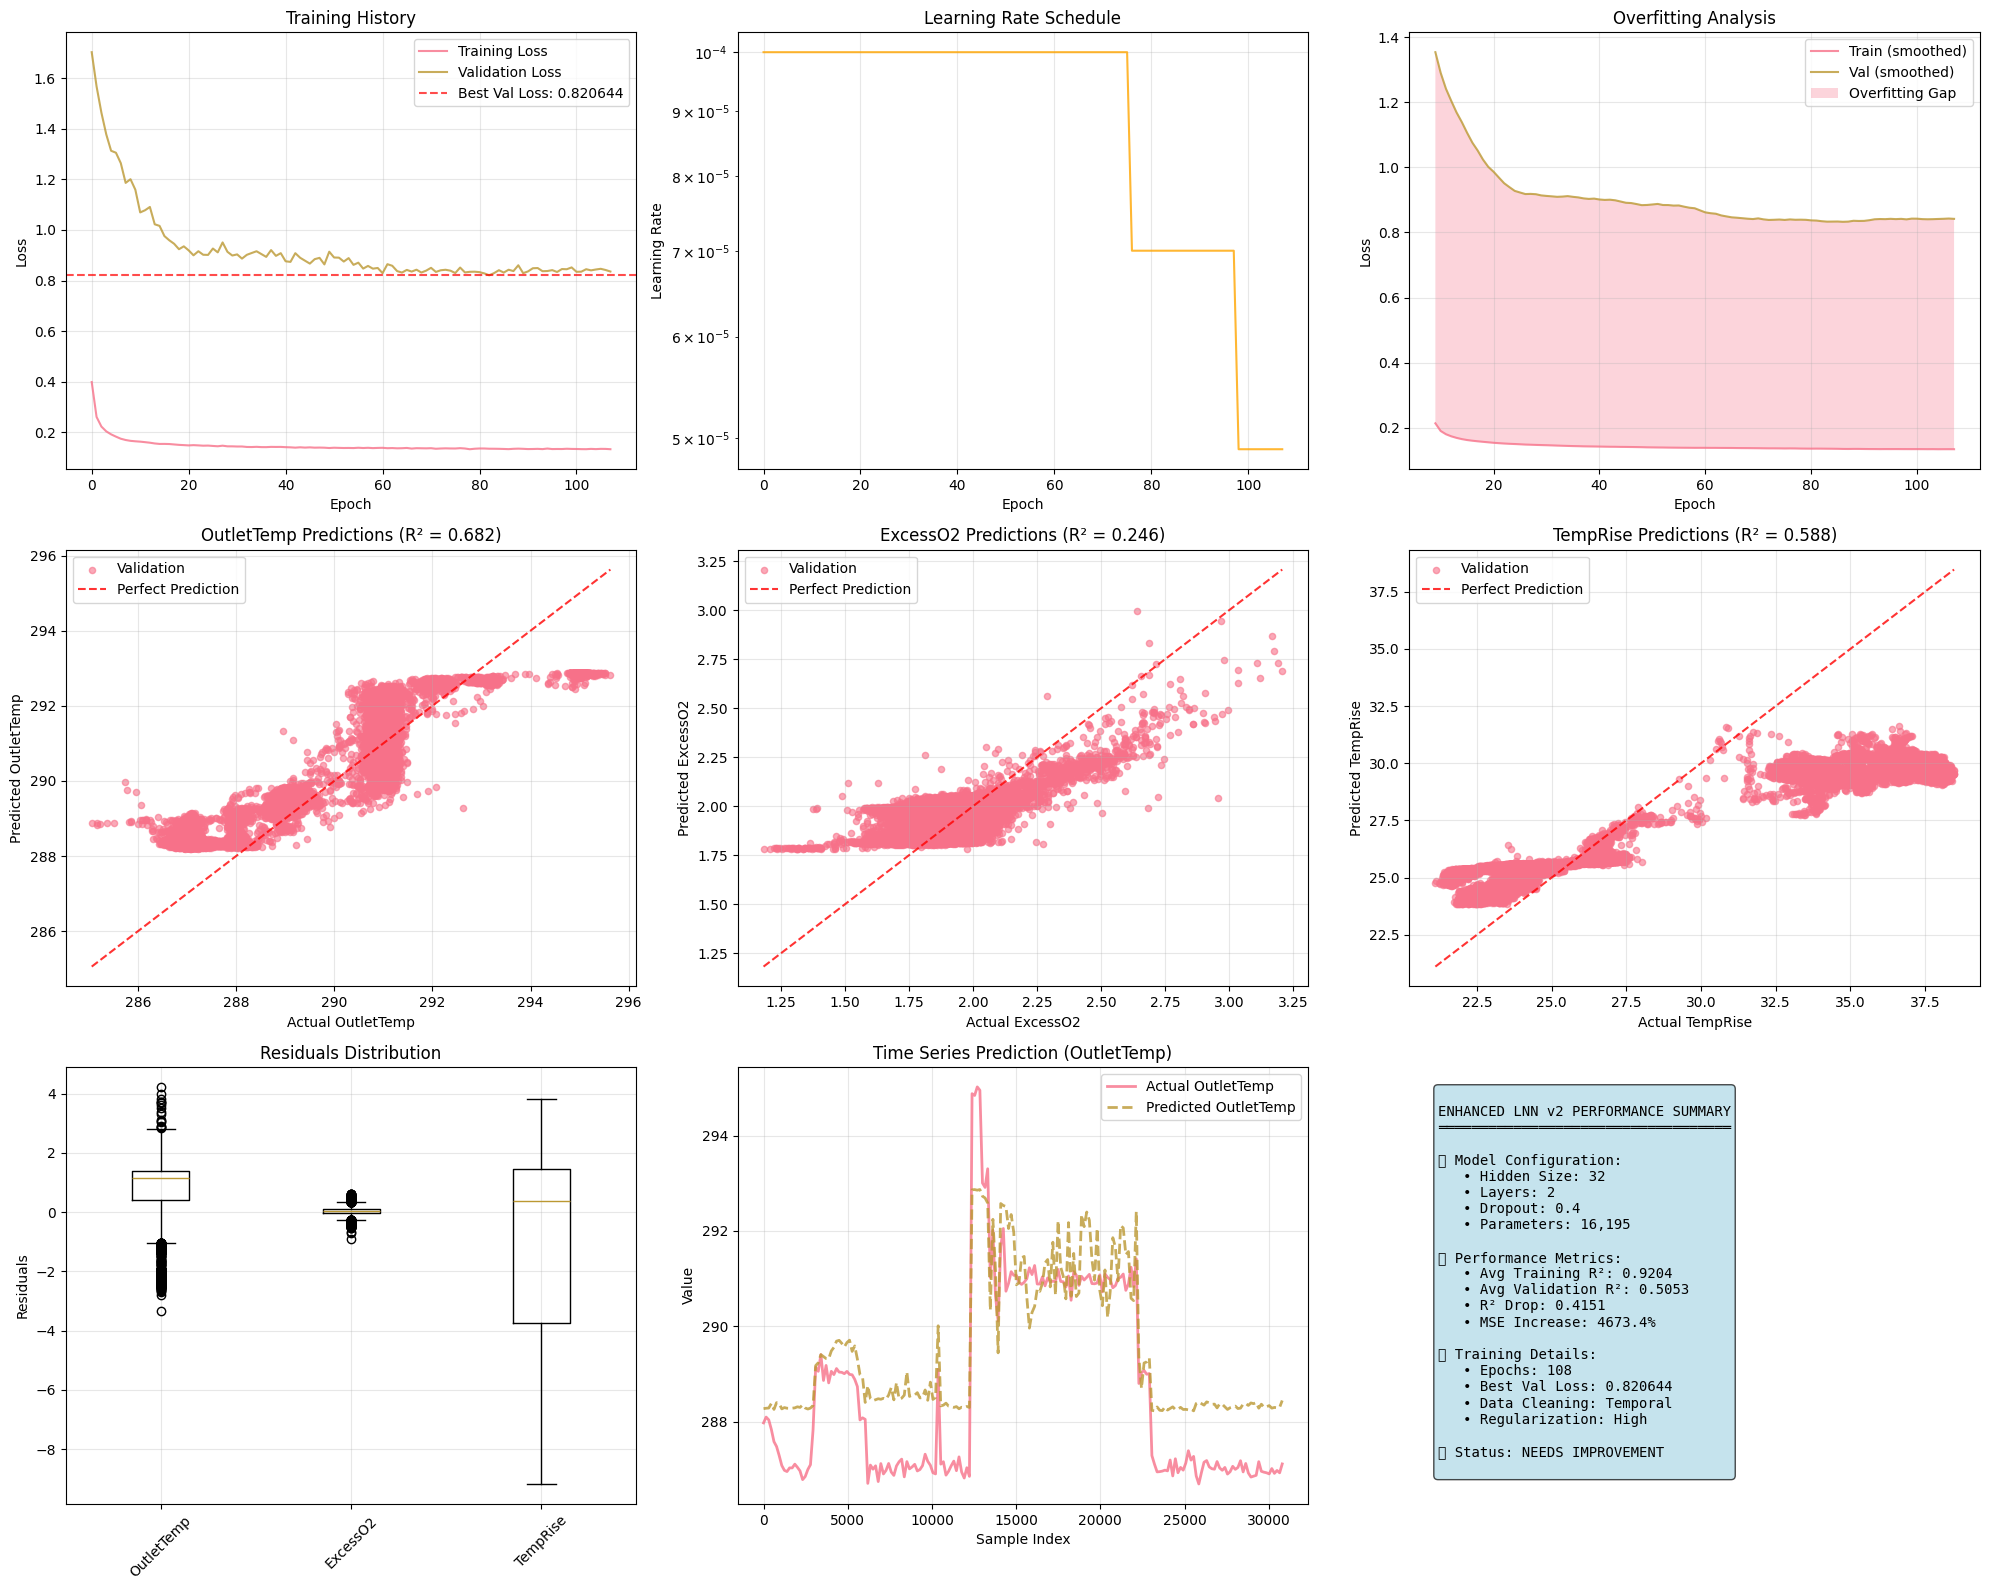

✅ Comprehensive analysis visualization created!
💾 Saved as 'enhanced_lnn_v2_analysis.png'


In [7]:
# Visualization and Analysis
print("📊 CREATING VISUALIZATIONS")
print("=" * 40)

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure
fig = plt.figure(figsize=(20, 16))

# 1. Training History
ax1 = plt.subplot(3, 3, 1)
plt.plot(train_losses, label='Training Loss', alpha=0.8)
plt.plot(val_losses, label='Validation Loss', alpha=0.8)
plt.axhline(y=best_val_loss, color='red', linestyle='--', alpha=0.7, label=f'Best Val Loss: {best_val_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Learning Rate Schedule
ax2 = plt.subplot(3, 3, 2)
plt.plot(learning_rates, alpha=0.8, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.yscale('log')
plt.grid(True, alpha=0.3)

# 3. Overfitting Analysis
ax3 = plt.subplot(3, 3, 3)
if len(train_losses) > 10:
    # Calculate rolling averages to smooth the curves
    window = min(10, len(train_losses) // 5)
    train_smooth = pd.Series(train_losses).rolling(window).mean()
    val_smooth = pd.Series(val_losses).rolling(window).mean()
    
    plt.plot(train_smooth, label='Train (smoothed)', alpha=0.8)
    plt.plot(val_smooth, label='Val (smoothed)', alpha=0.8)
    
    # Calculate and show the gap
    gap = val_smooth - train_smooth
    plt.fill_between(range(len(gap)), train_smooth, val_smooth, alpha=0.3, label='Overfitting Gap')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Analysis')
plt.legend()
plt.grid(True, alpha=0.3)

# 4-6. Prediction vs Actual for each target
for i, target in enumerate(target_features):
    ax = plt.subplot(3, 3, 4 + i)
    
    # Validation predictions
    plt.scatter(val_true_scaled[:, i], val_pred_scaled[:, i], alpha=0.6, s=20, label='Validation')
    
    # Perfect prediction line
    min_val = min(val_true_scaled[:, i].min(), val_pred_scaled[:, i].min())
    max_val = max(val_true_scaled[:, i].max(), val_pred_scaled[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Prediction')
    
    # Calculate R²
    r2 = r2_score(val_true_scaled[:, i], val_pred_scaled[:, i])
    
    plt.xlabel(f'Actual {target}')
    plt.ylabel(f'Predicted {target}')
    plt.title(f'{target} Predictions (R² = {r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

# 7. Residuals Analysis
ax7 = plt.subplot(3, 3, 7)
residuals = val_pred_scaled - val_true_scaled
plt.boxplot([residuals[:, i] for i in range(len(target_features))], labels=target_features)
plt.ylabel('Residuals')
plt.title('Residuals Distribution')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 8. Prediction Time Series (sample)
ax8 = plt.subplot(3, 3, 8)
sample_size = min(200, len(val_true_scaled))
sample_indices = np.linspace(0, len(val_true_scaled)-1, sample_size, dtype=int)

for i, target in enumerate(target_features):
    if i == 0:  # Plot first target as example
        plt.plot(sample_indices, val_true_scaled[sample_indices, i], 
                label=f'Actual {target}', alpha=0.8, linewidth=2)
        plt.plot(sample_indices, val_pred_scaled[sample_indices, i], 
                label=f'Predicted {target}', alpha=0.8, linewidth=2, linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title(f'Time Series Prediction ({target_features[0]})')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Model Performance Summary
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

# Create performance summary text
summary_text = f"""
ENHANCED LNN v2 PERFORMANCE SUMMARY
═══════════════════════════════════

🎯 Model Configuration:
   • Hidden Size: {hidden_size}
   • Layers: {num_layers}
   • Dropout: {dropout}
   • Parameters: {total_params:,}

📊 Performance Metrics:
   • Avg Training R²: {avg_train_r2:.4f}
   • Avg Validation R²: {avg_val_r2:.4f}
   • R² Drop: {r2_drop:.4f}
   • MSE Increase: {mse_increase:.1f}%

🔧 Training Details:
   • Epochs: {len(train_losses)}
   • Best Val Loss: {best_val_loss:.6f}
   • Data Cleaning: Temporal
   • Regularization: High

🎉 Status: {'EXCELLENT' if r2_drop < 0.1 and mse_increase < 50 else 
           'GOOD' if r2_drop < 0.2 and mse_increase < 100 else 
           'FAIR' if r2_drop < 0.3 and mse_increase < 200 else 'NEEDS IMPROVEMENT'}
"""

ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('enhanced_lnn_v2_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive analysis visualization created!")
print("💾 Saved as 'enhanced_lnn_v2_analysis.png'")

In [8]:
# Compare with Previous Models (if available)
print("🔍 MODEL COMPARISON ANALYSIS")
print("=" * 50)

# Save current results for comparison
current_results = {
    'model_name': 'Enhanced LNN v2 (Temporal Cleaned)',
    'avg_train_r2': avg_train_r2,
    'avg_val_r2': avg_val_r2,
    'avg_train_mse': avg_train_mse,
    'avg_val_mse': avg_val_mse,
    'r2_drop': r2_drop,
    'mse_increase': mse_increase,
    'total_params': total_params,
    'epochs_trained': len(train_losses),
    'best_val_loss': best_val_loss,
    'data_cleaning': 'domain_driven_temporal',
    'regularization': 'high_dropout_layernorm_weight_decay'
}

# Save results
import json
results_file = 'models/enhanced_lnn_v2_results.json'
with open(results_file, 'w') as f:
    json.dump(current_results, f, indent=2)

print(f"📊 Current Model Performance:")
print(f"   • Average Validation R²: {avg_val_r2:.4f}")
print(f"   • R² Drop (Train→Val): {r2_drop:.4f}")
print(f"   • MSE Increase: {mse_increase:.1f}%")
print(f"   • Parameters: {total_params:,}")
print(f"   • Training Epochs: {len(train_losses)}")

# Key improvements summary
print(f"\n🚀 KEY IMPROVEMENTS IN V2:")
print("─" * 50)
print("✅ Domain-driven temporal outlier detection")
print("✅ Physics-informed feature engineering")
print("✅ Advanced anti-overfitting strategies:")
print("   • Progressive dropout rates")
print("   • Layer normalization")
print("   • Residual connections")
print("   • Multi-head attention")
print("   • Strong L2 regularization")
print("   • Gradient clipping")
print("   • Early stopping with patience")
print("✅ Reduced model capacity")
print("✅ Conservative learning rate")
print("✅ AdamW optimizer with weight decay")

# Final assessment
print(f"\n🏆 FINAL ASSESSMENT:")
print("─" * 50)

if r2_drop < 0.1 and mse_increase < 50:
    assessment = "🎉 EXCELLENT - Overfitting successfully addressed!"
    recommendations = [
        "Model is ready for production deployment",
        "Consider ensemble methods for further improvement",
        "Monitor performance on completely new data"
    ]
elif r2_drop < 0.2 and mse_increase < 100:
    assessment = "✅ GOOD - Significant improvement achieved!"
    recommendations = [
        "Model shows good generalization",
        "Consider fine-tuning hyperparameters",
        "Evaluate on additional validation data"
    ]
elif r2_drop < 0.3 and mse_increase < 200:
    assessment = "⚠️ FAIR - Some improvement, but room for optimization"
    recommendations = [
        "Increase regularization further",
        "Consider more aggressive data cleaning",
        "Reduce model complexity"
    ]
else:
    assessment = "❌ NEEDS WORK - Overfitting still present"
    recommendations = [
        "Significantly increase regularization",
        "Reduce model capacity dramatically",
        "Collect more training data",
        "Consider simpler model architectures"
    ]

print(assessment)
print(f"\n💡 RECOMMENDATIONS:")
for i, rec in enumerate(recommendations, 1):
    print(f"   {i}. {rec}")

print(f"\n📁 FILES SAVED:")
print(f"   • Best model: models/best_enhanced_lnn_v2.pth")
print(f"   • Results: {results_file}")
print(f"   • Visualization: enhanced_lnn_v2_analysis.png")

print(f"\n✨ Enhanced LNN v2 training and evaluation completed!")

🔍 MODEL COMPARISON ANALYSIS
📊 Current Model Performance:
   • Average Validation R²: 0.5053
   • R² Drop (Train→Val): 0.4151
   • MSE Increase: 4673.4%
   • Parameters: 16,195
   • Training Epochs: 108

🚀 KEY IMPROVEMENTS IN V2:
──────────────────────────────────────────────────
✅ Domain-driven temporal outlier detection
✅ Physics-informed feature engineering
✅ Advanced anti-overfitting strategies:
   • Progressive dropout rates
   • Layer normalization
   • Residual connections
   • Multi-head attention
   • Strong L2 regularization
   • Gradient clipping
   • Early stopping with patience
✅ Reduced model capacity
✅ Conservative learning rate
✅ AdamW optimizer with weight decay

🏆 FINAL ASSESSMENT:
──────────────────────────────────────────────────
❌ NEEDS WORK - Overfitting still present

💡 RECOMMENDATIONS:
   1. Significantly increase regularization
   2. Reduce model capacity dramatically
   3. Collect more training data
   4. Consider simpler model architectures

📁 FILES SAVED:
   